 1. What is Boosting in Machine Learning? Explain how it improves weak
learners.
- Boosting in Machine Learning is an ensemble learning technique that combines multiple weak learners to create a strong predictive model. The key idea is to train models sequentially, where each new model focuses on correcting the errors made by the previous ones.
- Boosting converts multiple weak learners into a strong learner by training models sequentially, focusing on mistakes, and combining predictions.


How Boosting Improves Weak Learners

Boosting improves weak learners in several ways:

1. Focuses on Difficult Samples

Misclassified data points receive higher weights, forcing later models to learn those patterns.

2. Sequential Error Correction

Each model tries to correct mistakes made by earlier models, gradually improving performance.

3. Reduces Bias and Variance

Combining multiple learners helps produce a more stable and accurate model.

4. Builds a Strong Learner

The final model becomes a strong classifier even though individual models are weak.

2. What is the difference between AdaBoost and Gradient Boosting in terms
of how models are trained?
- Both AdaBoost and Gradient Boosting are boosting techniques in Machine Learning, but they differ mainly in how they train models and handle errors.
- | Feature         | AdaBoost                                  | Gradient Boosting                 |
| --------------- | ----------------------------------------- | --------------------------------- |
| Error handling  | Increases weight of misclassified samples | Fits new model to residual errors |
| Learning method | Weight adjustment                         | Gradient descent optimization     |
| Loss function   | Mainly exponential loss                   | Flexible (MSE, log-loss, etc.)    |


3. How does regularization help in XGBoost?
- XGBoost (Extreme Gradient Boosting) is an advanced implementation of Gradient Boosting used in Machine Learning. One of its key features is regularization, which helps control model complexity and improve generalization.
- Regularization is a technique used to prevent overfitting by adding a penalty term to the model’s objective function.
It discourages the model from becoming too complex.
- Regularization in XGBoost helps by reducing overfitting, controlling tree complexity, improving generalization, and making the model more stable through L1 and L2 penalty terms.

4. Why is CatBoost considered efficient for handling categorical data?
- CatBoost is considered highly efficient for handling categorical data in Machine Learning because it has built-in techniques to process categorical features directly, without requiring extensive preprocessing.
- CatBoost is efficient for categorical data because it automatically processes categorical features, uses target-based encoding, prevents data leakage with ordered boosting, and handles high-cardinality features effectively.


5. What are some real-world applications where boosting techniques are
preferred over bagging methods?
- Boosting techniques in Machine Learning are often preferred over bagging methods when the goal is to improve prediction accuracy by correcting previous errors. Algorithms like AdaBoost, Gradient Boosting, XGBoost, LightGBM, and CatBoost are widely used in many real-world applications.


1. Fraud Detection

Boosting models are commonly used in banking and financial systems to detect fraudulent transactions.

Why boosting works well:

It focuses on hard-to-detect patterns

Sequential learning helps capture rare fraud cases

Example:
Credit card fraud detection systems used by banks.

2. Recommendation Systems

Boosting algorithms help predict user preferences in recommendation engines.

Applications include:

Movie recommendations

Product suggestions

Companies like Amazon and Netflix use boosting-based models to improve recommendation accuracy.

3. Medical Diagnosis

Boosting models help identify diseases from medical data.

Examples:

Detecting Breast Cancer

Predicting Heart Disease

Boosting is preferred because it can detect subtle patterns in complex medical datasets.

4. Customer Churn Prediction

Telecommunication companies use boosting to predict which customers are likely to leave their services.

Example companies:

AT&T

Vodafone

Boosting helps capture complex relationships between customer behavior and churn.

5. Search Ranking and Click Prediction

Boosting algorithms are widely used for ranking web pages and predicting ad clicks.

Example:

Google search ranking systems.

Boosting performs well because it can learn fine-grained ranking patterns.

6. Image and Object Detection

Boosting techniques are used in computer vision tasks.

Example:

AdaBoost in the Viola–Jones Object Detection Framework for face detection.

In [2]:
# <!-- 6.  Write a Python program to:
# ● Train an AdaBoost Classifier on the Breast Cancer dataset
# ● Print the model accuracy -->

# <!-- Datasets:
# ● Use sklearn.datasets.load_breast_cancer() for classification tasks.
# ● Use sklearn.datasets.fetch_california_housing() for regression
# tasks. -->


# Import required libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

# Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create AdaBoost classifier
model = AdaBoostClassifier(n_estimators=50, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print the result
print("Model Accuracy:", accuracy)


Model Accuracy: 0.9649122807017544


In [3]:
# 7. Write a Python program to:
# ● Train a Gradient Boosting Regressor on the California Housing dataset
# ● Evaluate performance using R-squared score

# Import required libraries
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

# Load the California Housing dataset
data = fetch_california_housing()
X = data.data
y = data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Gradient Boosting Regressor model
model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model using R-squared score
r2 = r2_score(y_test, y_pred)

# Print the result
print("R-squared Score:", r2)

R-squared Score: 0.7756446042829697


In [12]:
# 8. Write a Python program to:
# ● Train an XGBoost Classifier on the Breast Cancer dataset
# ● Tune the learning rate using GridSearchCV
# ● Print the best parameters and accuracy


!pip install xgboost

# Import required libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

# Load the dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create XGBoost classifier
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Define parameter grid for learning rate
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2]
}

# Apply GridSearchCV
grid = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

# Best model
best_model = grid.best_estimator_

# Predictions
y_pred = best_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print results
print("Best Parameters:", grid.best_params_)
print("Model Accuracy:", accuracy)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:52:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:52:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:52:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:52:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Best Parameters: {'learning_rate': 0.2}
Model Accuracy: 0.956140350877193


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:52:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00


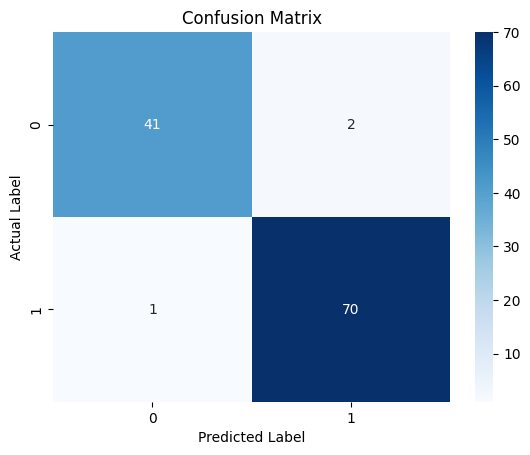

In [11]:
# 9. Write a Python program to:
# ● Train a CatBoost Classifier
# ● Plot the confusion matrix using seaborn

# Install CatBoost if not already installed
!pip install catboost

# Import required libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from catboost import CatBoostClassifier
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train CatBoost Classifier
model = CatBoostClassifier(verbose=0)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix using seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

10. You're working for a FinTech company trying to predict loan default using
customer demographics and transaction behavior.
The dataset is imbalanced, contains missing values, and has both numeric and
categorical features.
Describe your step-by-step data science pipeline using boosting techniques:
● Data preprocessing & handling missing/categorical values
● Choice between AdaBoost, XGBoost, or CatBoost
● Hyperparameter tuning strategy
● Evaluation metrics you'd choose and why
● How the business would benefit from your model



- Here’s a **step-by-step data science pipeline** for predicting **loan default** in a **FinTech company**, tailored to your dataset characteristics and the use of **boosting techniques**:

---

## **1️⃣ Data Preprocessing**

### a) Handling Missing Values

* **Numerical features:**

  * Impute missing values with **median** (robust to outliers) or use **KNN imputer** if relationships exist.
* **Categorical features:**

  * Impute missing values with a **new category** like `"Unknown"` or **mode**.
* **Boosting benefit:**

  * Algorithms like **XGBoost** and **CatBoost** can **handle missing values internally**, but explicit imputation is often safer for interpretability.

### b) Encoding Categorical Features

* **Options:**

  * **CatBoost:** can handle categorical features natively → **no one-hot encoding needed**.
  * **XGBoost / AdaBoost:** requires **one-hot or target encoding**.
* Since the dataset is **mixed type**, CatBoost is very efficient.

### c) Scaling / Normalization

* Not required for **tree-based boosting models** like XGBoost, CatBoost, or AdaBoost.

---

## **2️⃣ Choice of Boosting Algorithm**

| Algorithm    | Strengths                                                                                        | Use Case Here                                                                           |
| ------------ | ------------------------------------------------------------------------------------------------ | --------------------------------------------------------------------------------------- |
| **AdaBoost** | Simple, works well with small datasets                                                           | May underperform on complex, imbalanced datasets                                        |
| **XGBoost**  | Fast, regularization, handles missing values                                                     | Great for numeric + encoded categorical features                                        |
| **CatBoost** | Native categorical handling, robust to imbalanced classes, ordered boosting prevents overfitting | **Best choice here** due to mixed data types and high cardinality categorical variables |

✅ **Recommendation:** **CatBoost**

---

## **3️⃣ Handling Imbalanced Classes**

* Techniques:

  * **Class weights**: assign higher weight to default class.
  * **SMOTE / ADASYN**: generate synthetic samples for minority class.
* CatBoost supports **`class_weights`** → avoids oversampling.

---

## **4️⃣ Hyperparameter Tuning Strategy**

### Important Parameters:

* **Learning rate (`eta`)**: 0.01 – 0.3
* **Number of trees (`iterations`)**: 100–1000
* **Depth of trees (`depth`)**: 4–10
* **L2 regularization (`l2_leaf_reg`)**
* **Subsampling (`subsample`)** and **feature fraction (`rsm`)**

### Tuning Approach:

* **Step 1:** Start with default parameters → get baseline performance.
* **Step 2:** Use **GridSearchCV** or **RandomizedSearchCV** with 3–5 fold cross-validation.
* **Step 3:** Focus on **learning rate vs. iterations trade-off** (lower learning rate + more trees → better generalization).
* **Step 4:** Use **early stopping** on validation set to prevent overfitting.

---

## **5️⃣ Evaluation Metrics**

Since the dataset is **imbalanced**, **accuracy alone is misleading**. Better choices:

* **Precision & Recall** → to measure **how well we catch defaulters (positive class)**
* **F1-score** → balance between precision & recall
* **ROC-AUC / PR-AUC** → probability-based metric, shows separability
* **Confusion matrix** → visualize true positives vs false positives

💡 **Priority for business:**

* Minimize **false negatives** → predicting a defaulter as non-defaulter is costly.

---

## **6️⃣ Pipeline Summary**

1. **Data Cleaning & Missing Value Imputation**
2. **Categorical Feature Handling** (CatBoost native encoding)
3. **Train-Test Split / Cross-Validation**
4. **Train CatBoost Classifier** with class weights
5. **Hyperparameter Tuning** with GridSearchCV / early stopping
6. **Evaluate Model** using ROC-AUC, F1-score, confusion matrix
7. **Interpret Feature Importance** → help business understand risk factors

---

## **7️⃣ Business Benefit**

* **Reduce financial risk:** better prediction of defaulters → fewer losses
* **Targeted interventions:** offer customized repayment plans or risk-based interest rates
* **Regulatory compliance:** explainable boosting models help in **audit & reporting**
* **Resource optimization:** focus collections on high-risk loans, reducing operational cost

---

✅ **Key Takeaway:**
**CatBoost** is ideal here because it **handles categorical features naturally, deals with missing values, allows class weighting for imbalance, and provides feature importance**. Combined with careful **hyperparameter tuning** and **proper evaluation metrics**, it maximizes predictive power while aligning with business objectives.

---